# Model Testing — No Race Features

This notebook replicates `model_testing.ipynb` with `race_*` columns removed from training data.

**Hypothesis (proxy bias):** Even without direct access to race, models may still produce
systematically different prediction errors across racial groups — because features like
`priors_count` and `age_at_event` act as proxies for race due to systemic over-policing.

The per-race error breakdown at the end is the key comparison against `model_testing.ipynb`.

# 0) Environment

### Imports and Constants

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, learning_curve
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import ElasticNet, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from mord import LogisticAT


DATA_PATH = '../../data/compas_preprocessed.csv'
_RS = 42
_TARGET = 'decile_score'
_TEST_PERCENTAGE = 0.2
_DROP = 'is_recid'
RACE_COLS = ['race_african-american', 'race_caucasian', 'race_hispanic']

### Import data, drop race features, isolate target

In [2]:
df = pd.read_csv(DATA_PATH)

# Preserve race labels before dropping — used later for bias analysis
X_race_info = df[RACE_COLS].copy()

y = df.pop(_TARGET)
X = df.drop(columns=RACE_COLS + [_DROP])

print(f'Dataset: {X.shape[0]} rows, {X.shape[1]} features (race columns removed)')
print(f'Removed columns: {RACE_COLS}')

Dataset: 6172 rows, 18 features (race columns removed)
Removed columns: ['race_african-american', 'race_caucasian', 'race_hispanic']


### Helper functions

In [3]:
def get_regression_metrics(model, X_test, y_test, X_train, y_train):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    tr2 = r2_score(y_train, y_train_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2, tr2

def print_regression_metrics(test_mae, test_mse, test_rmse, test_r2, train_r2):
    print(f'\nTraining R2: {train_r2:.4f}')
    print(f'Test R2:     {test_r2:.4f}')
    print(f'Difference:  {train_r2 - test_r2:.4f}')
    print()
    print(f'MAE:  {test_mae:.4f}')
    print(f'MSE:  {test_mse:.4f}')
    print(f'RMSE: {test_rmse:.4f}')

from functools import partial
GridSearchCV = partial(GridSearchCV, n_jobs=-1)

# 1) Train and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=_RS, test_size=_TEST_PERCENTAGE,
    stratify=y,
)

# Align saved race labels to the test set by index
X_test_race_info = X_race_info.loc[X_test.index]

# 2) Linear Models

> **AI Acknowledgements** (Gemini):
- **Quantile** and **Ordinal** regressions improve the model's ability to handle discrete, ranked scales.
- **TransformedTargetRegressor** (TTR) stabilises variance by reducing skew via log transform.
- **SplineTransformer** was suggested to explore non-linear flexibility beyond the ~0.5 R² ceiling.

### ElasticNet (Polynomial)

##### Model pipeline

In [5]:
model_elastic_net_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000, tol=0.01),
)

##### Hyper Parameter Optimization

In [6]:
param_grid = {
    'elasticnet__alpha': [0.01, 0.1, 1.0],
    'elasticnet__l1_ratio': [0.5, 0.9, 0.99],
    'polynomialfeatures__degree': [1, 2]
}

model_elastic_net = GridSearchCV(
    model_elastic_net_pipeline, param_grid,
    cv=5, scoring='neg_mean_squared_error', refit=True
)
model_elastic_net.fit(X_train, y_train)

print(f'Best Params: {model_elastic_net.best_params_}')

Best Params: {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.99, 'polynomialfeatures__degree': 2}


##### Baseline metrics

In [7]:
metrics = get_regression_metrics(model_elastic_net, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics)


Training R2: 0.4864
Test R2:     0.4964
Difference:  -0.0099

MAE:  1.6113
MSE:  4.0610
RMSE: 2.0152


### Quantile Regression

##### Model pipeline

In [8]:
model_quantile_base_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    QuantileRegressor(quantile=0.5, alpha=1.0, solver='highs'),
)

model_quantile_pipeline = TransformedTargetRegressor(
    regressor=model_quantile_base_pipeline,
    func=np.log,
    inverse_func=np.exp
)

##### Hyper Parameter Optimization

In [9]:
param_grid_quantile = {
    'regressor__quantileregressor__quantile': [0.25, 0.5, 0.75],
    'regressor__quantileregressor__alpha': [0.01, 0.1, 1.0],
    'regressor__polynomialfeatures__degree': [1, 2]
}

model_quantile = GridSearchCV(
    model_quantile_pipeline, param_grid_quantile,
    cv=5, scoring='neg_mean_squared_error', refit=True
)
model_quantile.fit(X_train, y_train)

print(f'Best Params: {model_quantile.best_params_}')

Best Params: {'regressor__polynomialfeatures__degree': 2, 'regressor__quantileregressor__alpha': 0.01, 'regressor__quantileregressor__quantile': 0.5}


##### Metrics

In [10]:
metrics_quantile = get_regression_metrics(model_quantile, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_quantile)


Training R2: 0.4441
Test R2:     0.4703
Difference:  -0.0262

MAE:  1.5630
MSE:  4.2711
RMSE: 2.0667


### Ordinal Regression

##### Model pipeline

In [11]:
model_ordinal_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticAT(alpha=1.0)
)

##### Hyper Parameter Optimization

In [12]:
param_grid_ordinal = {
    'logisticat__alpha': [0.01, 0.1, 1.0],
    'polynomialfeatures__degree': [1, 2]
}

model_ordinal = GridSearchCV(
    model_ordinal_pipeline, param_grid_ordinal,
    cv=5, scoring='neg_mean_squared_error', refit=True
)
model_ordinal.fit(X_train, y_train)

print(f'Best Params: {model_ordinal.best_params_}')

Best Params: {'logisticat__alpha': 0.01, 'polynomialfeatures__degree': 1}


##### Metrics

In [13]:
metrics_ordinal = get_regression_metrics(model_ordinal, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_ordinal)


Training R2: 0.4494
Test R2:     0.4707
Difference:  -0.0213

MAE:  1.5296
MSE:  4.2680
RMSE: 2.0659


### ElasticNet (Spline + TTR)

##### Model pipeline

In [14]:
model_elasticnet_spline_base_pipeline = make_pipeline(
    SplineTransformer(n_knots=5, degree=3),
    StandardScaler(),
    ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000, tol=0.01),
)

model_elasticnet_spline_pipeline = TransformedTargetRegressor(
    regressor=model_elasticnet_spline_base_pipeline,
    func=np.log,
    inverse_func=np.exp
)

##### Hyper Parameter Optimization

In [15]:
param_grid_elasticnet_spline = {
    'regressor__splinetransformer__n_knots': [5, 8],
    'regressor__elasticnet__alpha': [0.01, 0.1, 1.0],
    'regressor__elasticnet__l1_ratio': [0.5, 0.9, 0.99]
}

model_elasticnet_spline = GridSearchCV(
    model_elasticnet_spline_pipeline, param_grid_elasticnet_spline,
    cv=5, scoring='neg_mean_squared_error', refit=True
)
model_elasticnet_spline.fit(X_train, y_train)

print(f'Best Params: {model_elasticnet_spline.best_params_}')

Best Params: {'regressor__elasticnet__alpha': 0.01, 'regressor__elasticnet__l1_ratio': 0.5, 'regressor__splinetransformer__n_knots': 5}


##### Metrics

In [16]:
metrics_elasticnet_spline = get_regression_metrics(model_elasticnet_spline, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_elasticnet_spline)


Training R2: 0.4468
Test R2:     0.4724
Difference:  -0.0256

MAE:  1.5522
MSE:  4.2543
RMSE: 2.0626


# 3) Non-Linear Models

> R² is still expected to be capped near ~0.5 — removing race features should not dramatically
> change predictive performance if bias is mediated through criminal history proxies.

### Random Forest

##### Model pipeline

In [17]:
model_random_forest_pipeline = make_pipeline(
    RandomForestRegressor(
        n_estimators=200,
        max_features='sqrt',
        random_state=_RS
    ),
)

##### Hyper parameter optimization

In [18]:
param_grid_random_forest = {
    'randomforestregressor__n_estimators': [100, 200, 300],
    'randomforestregressor__max_depth': [3, 6, 9],
    'randomforestregressor__min_samples_leaf': [1, 2, 4],
}

model_random_forest = GridSearchCV(
    estimator=model_random_forest_pipeline,
    param_grid=param_grid_random_forest,
    cv=5, scoring='neg_mean_absolute_error', refit=True
)
model_random_forest.fit(X_train, y_train)

print(f'Best Params: {model_random_forest.best_params_}')

Best Params: {'randomforestregressor__max_depth': 9, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__n_estimators': 300}


##### Metrics

In [19]:
metrics_random_forest = get_regression_metrics(model_random_forest, X_test, y_test, X_train, y_train)
print_regression_metrics(*metrics_random_forest)


Training R2: 0.5616
Test R2:     0.4912
Difference:  0.0704

MAE:  1.6228
MSE:  4.1029
RMSE: 2.0256


# 3b) Classification into decile bins

##### Scoring

In [20]:
class_model = model_elasticnet_spline

class_y_pred = np.clip(np.round(class_model.best_estimator_.predict(X_test)).astype(int), 1, 10)
class_y_true = y_test.astype(int)

class_precision = precision_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_recall    = recall_score(class_y_true, class_y_pred, average='weighted', zero_division=0)
class_f1        = f1_score(class_y_true, class_y_pred, average='weighted', zero_division=0)

print(f'Precision (weighted): {class_precision:.4f}')
print(f'Recall    (weighted): {class_recall:.4f}')
print(f'F1        (weighted): {class_f1:.4f}')
print()
print(classification_report(class_y_true, class_y_pred, zero_division=0))

Precision (weighted): 0.3497
Recall    (weighted): 0.2356
F1        (weighted): 0.2486

              precision    recall  f1-score   support

           1       0.89      0.33      0.49       257
           2       0.21      0.35      0.26       165
           3       0.15      0.24      0.19       130
           4       0.19      0.29      0.23       133
           5       0.16      0.24      0.19       116
           6       0.13      0.16      0.15       106
           7       0.12      0.10      0.11        99
           8       0.20      0.11      0.14        84
           9       0.33      0.07      0.12        84
          10       0.56      0.15      0.23        61

    accuracy                           0.24      1235
   macro avg       0.30      0.20      0.21      1235
weighted avg       0.35      0.24      0.25      1235



##### Visualization

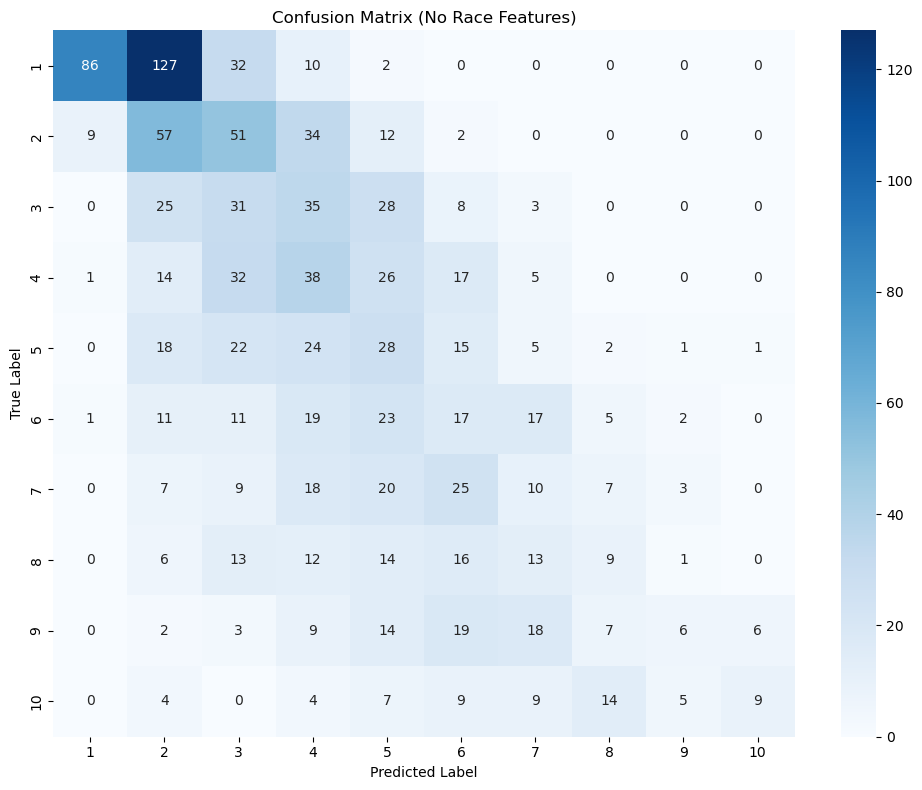

In [21]:
cm = confusion_matrix(y_test, class_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix (No Race Features)')
plt.tight_layout()
plt.show()

# 4) Learning Curves

> AI Acknowledgement: This section was made with the help of Claude Sonnet 4.6.

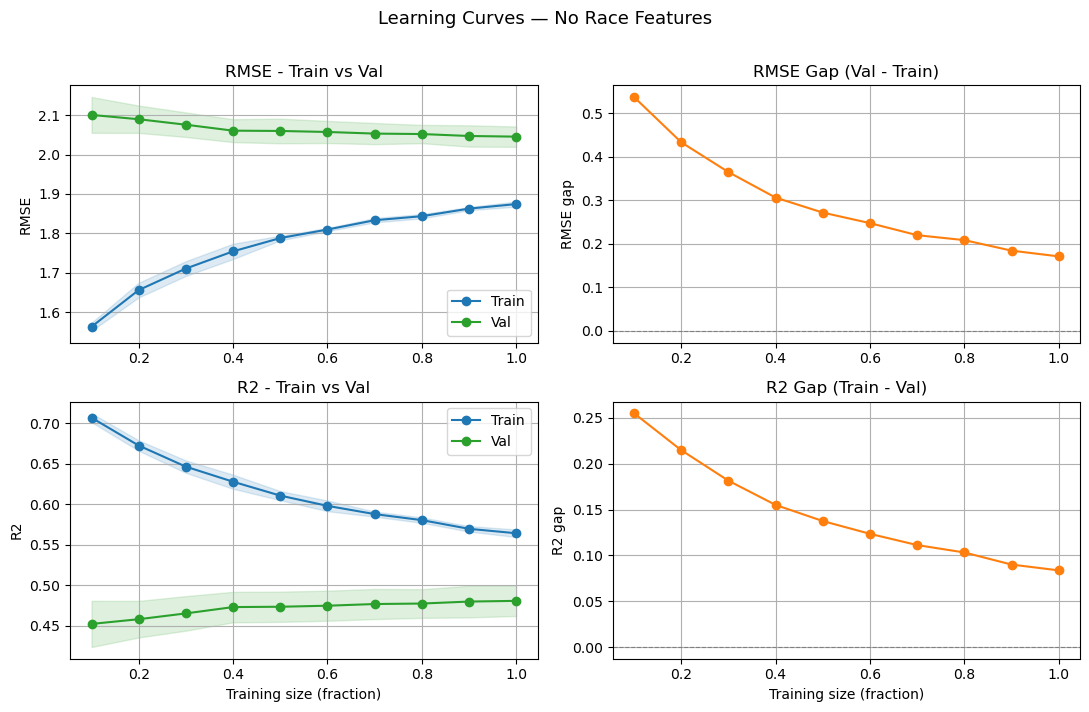

In [22]:
sizes = np.linspace(0.1, 1.0, 10)
lc_model = model_random_forest

def _lc(scoring):
    _, tr, vl = learning_curve(
        lc_model.best_estimator_, X, y,
        train_sizes=sizes, cv=5, scoring=scoring, n_jobs=-1
    )
    return tr, vl

tr_mse, vl_mse = _lc('neg_mean_squared_error')
tr_r2,  vl_r2  = _lc('r2')

tr_rmse_m, tr_rmse_s = np.sqrt(-tr_mse).mean(1), np.sqrt(-tr_mse).std(1)
vl_rmse_m, vl_rmse_s = np.sqrt(-vl_mse).mean(1), np.sqrt(-vl_mse).std(1)
tr_r2_m,   tr_r2_s   = tr_r2.mean(1), tr_r2.std(1)
vl_r2_m,   vl_r2_s   = vl_r2.mean(1), vl_r2.std(1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

ax = axes[0, 0]
ax.plot(sizes, tr_rmse_m, marker='o', label='Train', color='tab:blue')
ax.plot(sizes, vl_rmse_m, marker='o', label='Val',   color='tab:green')
ax.fill_between(sizes, tr_rmse_m - tr_rmse_s, tr_rmse_m + tr_rmse_s, alpha=0.15, color='tab:blue')
ax.fill_between(sizes, vl_rmse_m - vl_rmse_s, vl_rmse_m + vl_rmse_s, alpha=0.15, color='tab:green')
ax.set_title('RMSE - Train vs Val')
ax.set_ylabel('RMSE')
ax.legend()
ax.grid(True)

ax = axes[0, 1]
ax.plot(sizes, vl_rmse_m - tr_rmse_m, marker='o', color='tab:orange')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('RMSE Gap (Val - Train)')
ax.set_ylabel('RMSE gap')
ax.grid(True)

ax = axes[1, 0]
ax.plot(sizes, tr_r2_m, marker='o', label='Train', color='tab:blue')
ax.plot(sizes, vl_r2_m, marker='o', label='Val',   color='tab:green')
ax.fill_between(sizes, tr_r2_m - tr_r2_s, tr_r2_m + tr_r2_s, alpha=0.15, color='tab:blue')
ax.fill_between(sizes, vl_r2_m - vl_r2_s, vl_r2_m + vl_r2_s, alpha=0.15, color='tab:green')
ax.set_title('R2 - Train vs Val')
ax.set_ylabel('R2')
ax.set_xlabel('Training size (fraction)')
ax.legend()
ax.grid(True)

ax = axes[1, 1]
ax.plot(sizes, tr_r2_m - vl_r2_m, marker='o', color='tab:orange')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('R2 Gap (Train - Val)')
ax.set_ylabel('R2 gap')
ax.set_xlabel('Training size (fraction)')
ax.grid(True)

plt.suptitle('Learning Curves — No Race Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 5) Racial Bias Analysis

The models were trained **without** race features. We now check whether racial disparities
persist in the predictions — evidence of **proxy bias** through correlated features.

Compare the signed error plots here against `model_testing.ipynb` to see whether
removing race reduces or eliminates the directional bias.

We use the Random Forest as the reference model (highest R²).

### Feature Importance (Random Forest)

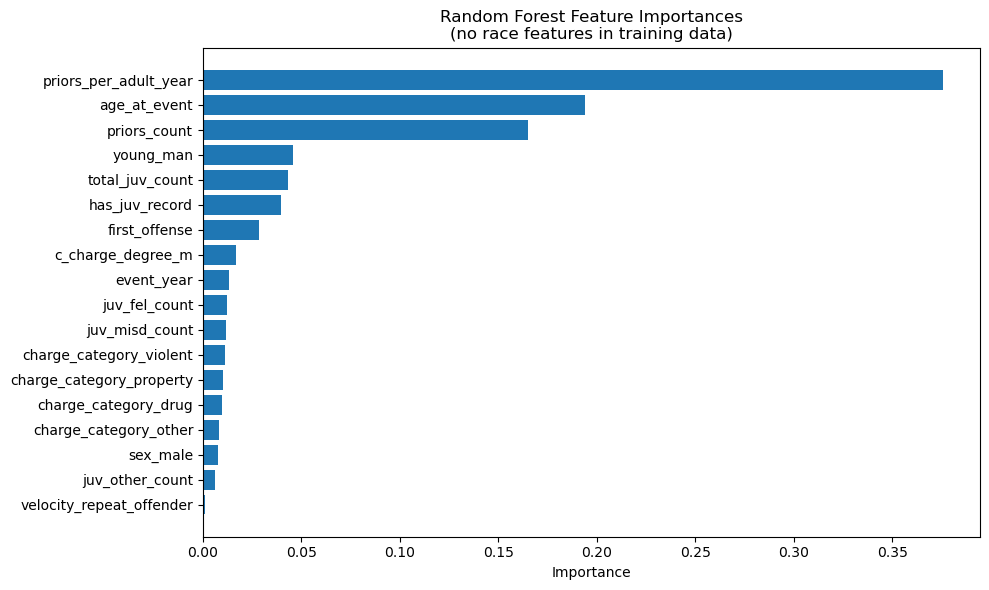

In [23]:
rf_estimator = model_random_forest.best_estimator_['randomforestregressor']
feature_names = X.columns.tolist()
importances = rf_estimator.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='#1f77b4')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importances\n(no race features in training data)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Per-Race Error Breakdown

Race labels are recovered from `X_test_race_info` (saved before training, never seen by the model).

**Signed error** (predicted − true):
- Positive → model over-predicts risk for this group
- Negative → model under-predicts risk

In [24]:
def decode_race(row):
    if row['race_african-american'] == 1:
        return 'african-american'
    elif row['race_caucasian'] == 1:
        return 'caucasian'
    elif row['race_hispanic'] == 1:
        return 'hispanic'
    else:
        return 'other'

analysis_df = X_test.copy()
analysis_df['race'] = X_test_race_info.apply(decode_race, axis=1).values
analysis_df['y_true'] = y_test.values
analysis_df['y_pred'] = model_random_forest.predict(X_test)
analysis_df['signed_error'] = analysis_df['y_pred'] - analysis_df['y_true']

In [25]:
race_metrics = analysis_df.groupby('race').apply(lambda g: pd.Series({
    'n': len(g),
    'mean_true_score': round(g['y_true'].mean(), 3),
    'mean_pred_score': round(g['y_pred'].mean(), 3),
    'mae': round(mean_absolute_error(g['y_true'], g['y_pred']), 4),
    'rmse': round(np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])), 4),
    'mean_signed_error': round(g['signed_error'].mean(), 4),
})).reset_index()

display(race_metrics)

/tmp/ipykernel_288861/3622651606.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_metrics = analysis_df.groupby('race').apply(lambda g: pd.Series({


,race,n,mean_true_score,mean_pred_score,mae,rmse,mean_signed_error
0,african-american,654.0,5.182,4.982,1.6925,2.1160,-0.1998
1,caucasian,416.0,3.541,3.812,1.5523,1.9380,0.2706
2,hispanic,95.0,3.632,4.152,1.5231,1.9072,0.5202
3,other,70.0,3.557,4.189,1.5266,1.8165,0.6315


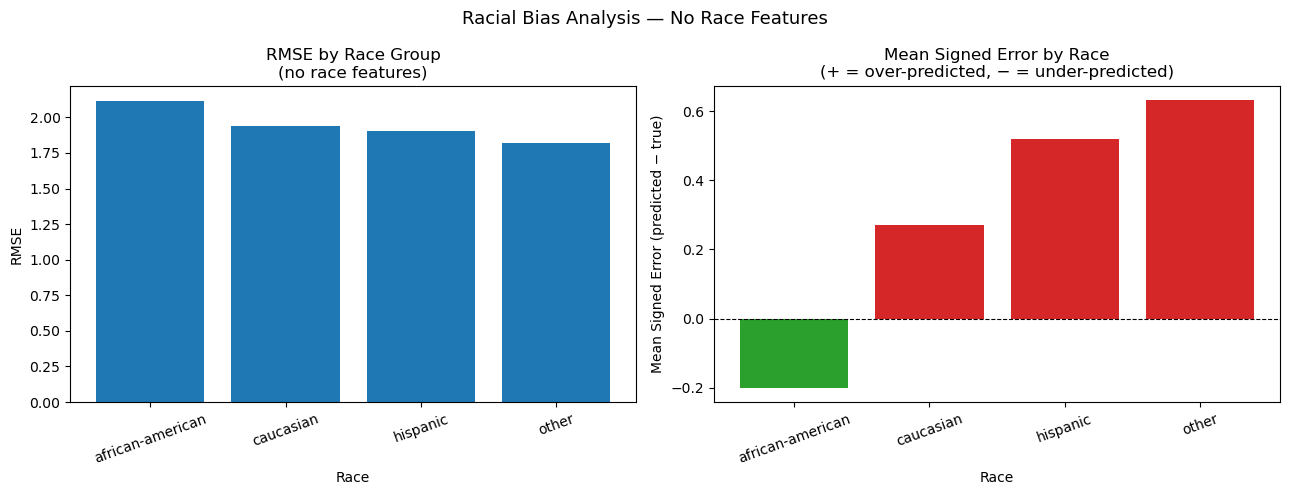

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(race_metrics['race'], race_metrics['rmse'], color='#1f77b4')
ax.set_title('RMSE by Race Group\n(no race features)')
ax.set_ylabel('RMSE')
ax.set_xlabel('Race')
ax.tick_params(axis='x', rotation=20)

ax = axes[1]
bar_colors = ['#d62728' if v > 0 else '#2ca02c' for v in race_metrics['mean_signed_error']]
ax.bar(race_metrics['race'], race_metrics['mean_signed_error'], color=bar_colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Signed Error by Race\n(+ = over-predicted, − = under-predicted)')
ax.set_ylabel('Mean Signed Error (predicted − true)')
ax.set_xlabel('Race')
ax.tick_params(axis='x', rotation=20)

plt.suptitle('Racial Bias Analysis — No Race Features', fontsize=13)
plt.tight_layout()
plt.show()

# 6) Save Models

In [27]:
MODELS_DIR = '../../models/score/no_race'
os.makedirs(MODELS_DIR, exist_ok=True)

models = {
    'elasticnet_polynomial': model_elastic_net,
    'quantile_ttr':          model_quantile,
    'ordinal':               model_ordinal,
    'elasticnet_spline_ttr': model_elasticnet_spline,
    'random_forest':         model_random_forest,
}

for name, model in models.items():
    path = os.path.join(MODELS_DIR, f'{name}.joblib')
    joblib.dump(model, path)
    print(f'Saved: {path}')

Saved: ../../models/score/no_race/elasticnet_polynomial.joblib
Saved: ../../models/score/no_race/quantile_ttr.joblib
Saved: ../../models/score/no_race/ordinal.joblib
Saved: ../../models/score/no_race/elasticnet_spline_ttr.joblib
Saved: ../../models/score/no_race/random_forest.joblib
